In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from Filtro_LS import *
from Funcoes_auxiliares import *
from Gerador_de_Sinais import main as gerador_sinal_entrada_saida
from numpy.fft import fft, fftfreq

In [17]:
def freq_sinal(sinal, dt):
    """
    fs = frequência de amostragem. Unidade: Hz.
    dt = 1/fs. tempo entre amostras # meu caso 25 * 10**-9

    fs = 40e6 # meu caso com t1 = np.arange(0, 400) * 25 * 10**-9
    sinal = seu_sinal
    """

    N = len(sinal)

    fft_vals = np.fft.fft(sinal)
    # dt = 1 / fs
    frequencias = np.fft.fftfreq(N, dt)
    espectro = fft(sinal)
    magnitude = np.abs(espectro)

    # pegar só parte positiva
    idx = np.where(frequencias >= 0)

    plt.plot(frequencias[idx], np.abs(fft_vals[idx]))
    plt.grid()
    plt.xlabel("Frequência (Hz)")
    plt.ylabel("Magnitude")
    plt.show()

In [ ]:
# Consantes & Variáveis #

quantidade_de_amostras = 75

dt = 25 * 10**-9  # tempo entre amostras. Dados proveniente do Shaper
fs = 1 / dt  # frequência de amostragem. 40 MHz
resoluçao = fs / quantidade_de_amostras  # Dados proveniente do Shaper.

In [21]:
sinal_original, Readout_Shaper = gerador_sinal_entrada_saida(
    quantidade_de_amostras, seed=42
)

sinal_estimado = filtro_LS_2(
    readout=Readout_Shaper,
    sinal_desejado=sinal_original,
    ordem_filter=7,
    delay=2,
)

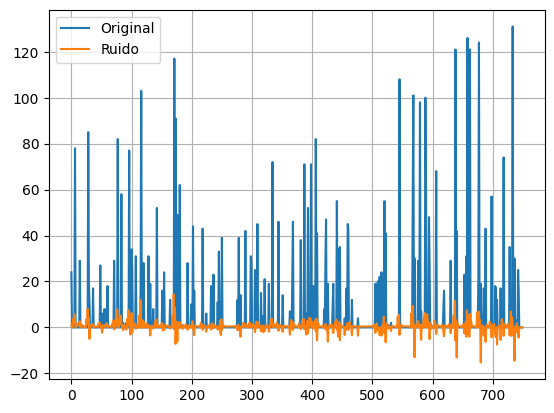

In [25]:
ruido = sinal_estimado - sinal_original  # dt_ruido = dt_sinal_original

plt.plot(sinal_original)
plt.plot(ruido)
plt.legend(["Original", "Ruido"])
# plt.ylim(-5, 165)
plt.grid()

In [ ]:
def freq(sinal):
    """
    retira-se a media para retirar o pico enorme em 0 Hz.
    """
    sinal1 = sinal - np.mean(sinal)
    freq_sinal(sinal1, 25 * 10**-9)

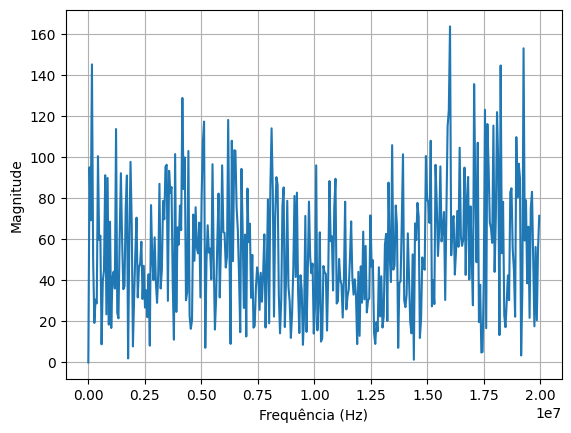

In [31]:
freq(ruido)

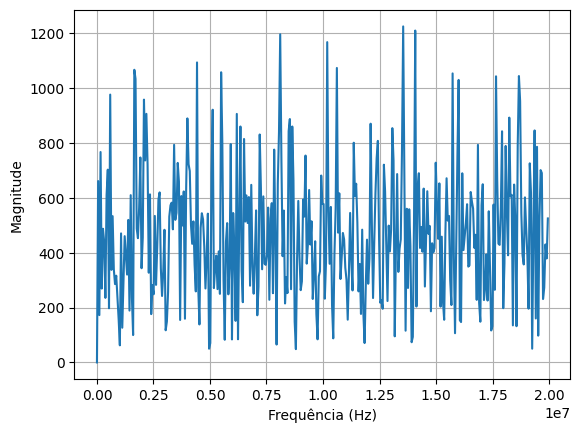

In [32]:
freq(sinal_original)

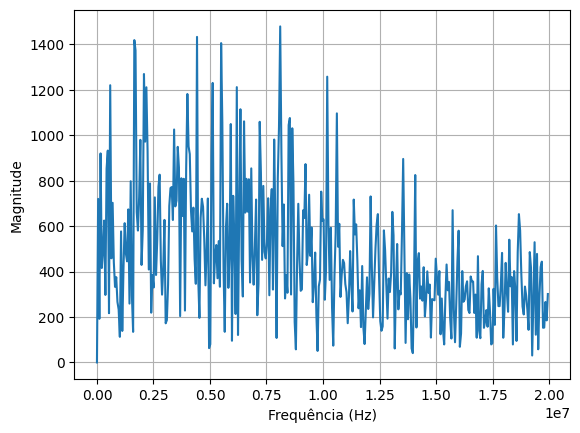

In [ ]:
freq(Readout_Shaper)

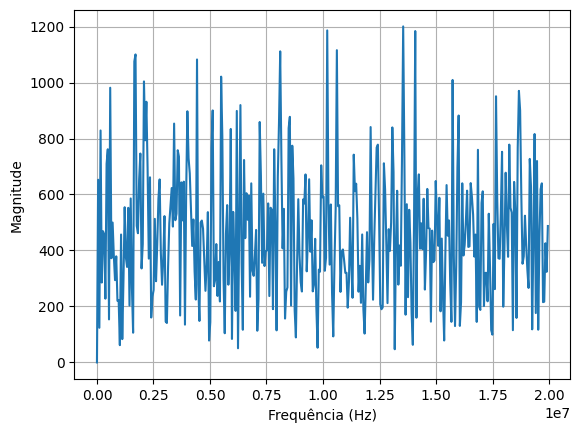

In [34]:
freq(sinal_estimado)

In [35]:
np.corrcoef(ruido, sinal_original)

array([[ 1.        , -0.20352379],
       [-0.20352379,  1.        ]])

In [37]:
erro = sinal_estimado - sinal_original

rms_erro = np.sqrt(np.mean(erro**2))
rms_sinal = np.sqrt(np.mean(sinal_original**2))

erro_relativo = rms_erro / rms_sinal
erro_relativo

np.float64(0.11382708389837581)

In [ ]:
np.mean(erro)

np.float64(0.4458352542260756)

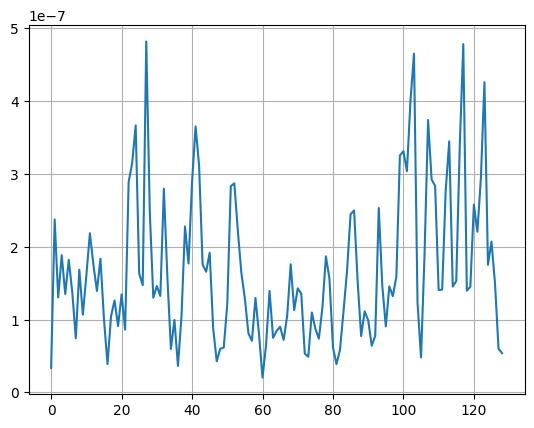

In [ ]:
from scipy.signal import welch

f, psd = welch(erro, fs=40e6)
plt.grid()
plt.plot(psd)

In [44]:
erro_sem_bias = erro - np.mean(erro)

rms_erro = np.sqrt(np.mean(erro_sem_bias**2))
rms_sinal = np.sqrt(np.mean(sinal_original**2))

erro_relativo_corrigido = rms_erro / rms_sinal
erro_relativo_corrigido

np.float64(0.11169162567502339)

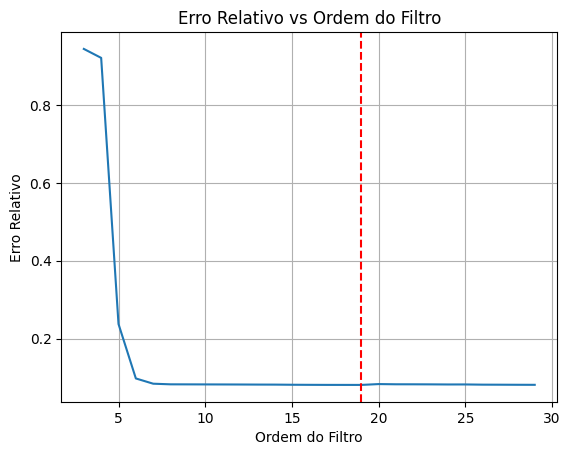

'\nComo interpretar o gráfico\nCaso 1: Curva desce e estabiliza\n\n→ Ordem insuficiente antes.\n→ Pode valer aumentar ordem.\n\nCaso 2: Curva desce e depois sobe\n\n→ Overfitting.\n→ Existe ordem ótima clara.\n\nCaso 3: Curva quase não muda\n\n→ Limitação estrutural do modelo.\n→ Trocar método pode ser mais útil que aumentar ordem.\n'

In [85]:
def calcular_erro_para_ordem(
    ordem,
    readout_shaper,
    sinal_desejado,
    delay,
):

    matriz_obs = matriz_observacao(readout_shaper, ordem_filtro=ordem)
    matriz_obs = np.column_stack([matriz_obs, np.ones(matriz_obs.shape[0])])

    end = matriz_obs.shape[0]

    aux_peso = (
        inversa(matriz_obs.T @ matriz_obs)
        @ matriz_obs.T
        @ sinal_desejado[delay : delay + end]
    )

    peso = np.flipud(aux_peso[:-1])
    bias = aux_peso[-1]

    # reconstrução do sinal
    sinal_estimado = matriz_obs[:, :-1] @ np.flipud(peso) + bias

    erro = sinal_estimado - sinal_desejado[delay : delay + end]

    rms_erro = np.sqrt(np.mean(erro**2))
    rms_sinal = np.sqrt(np.mean(sinal_desejado[delay : delay + end] ** 2))

    erro_relativo = rms_erro / rms_sinal

    return erro_relativo


# faixa de ordens para testar
ordens = range(3, 30)

erros = []

for ordem in ordens:
    # erro_rel, ordem_menor_erro = calcular_erro_para_ordem(
    erro_rel = calcular_erro_para_ordem(
        ordem,
        Readout_Shaper,
        sinal_original,
        2,
    )
    erros.append(erro_rel)
# print(f"{ordem_menor_erro = }")
plt.plot(ordens, erros)
plt.axvline(19, linestyle="--", color="red")
# plt.xlim(6,23)
# plt.ylim(0,0.20)
plt.xlabel("Ordem do Filtro")
plt.ylabel("Erro Relativo")
plt.title("Erro Relativo vs Ordem do Filtro")
plt.grid(True)
plt.show()

"""
Como interpretar o gráfico
Caso 1: Curva desce e estabiliza

→ Ordem insuficiente antes.
→ Pode valer aumentar ordem.

Caso 2: Curva desce e depois sobe

→ Overfitting.
→ Existe ordem ótima clara.

Caso 3: Curva quase não muda

→ Limitação estrutural do modelo.
→ Trocar método pode ser mais útil que aumentar ordem.
"""

In [86]:
def calcular_erro_para_ordem1(ordem, readout_shaper, sinal_desejado, delay):
    matriz_obs = matriz_observacao(readout_shaper, ordem_filtro=ordem)
    matriz_obs = np.column_stack([matriz_obs, np.ones(matriz_obs.shape[0])])

    end = matriz_obs.shape[0]
    aux_peso = (
        inversa(matriz_obs.T @ matriz_obs)
        @ matriz_obs.T
        @ sinal_desejado[delay : delay + end]
    )

    peso = np.flipud(aux_peso[:-1])
    bias = aux_peso[-1]

    sinal_estimado = matriz_obs[:, :-1] @ np.flipud(peso) + bias
    erro = sinal_estimado - sinal_desejado[delay : delay + end]

    rms_erro = np.sqrt(np.mean(erro**2))
    rms_sinal = np.sqrt(np.mean(sinal_desejado[delay : delay + end] ** 2))
    erro_relativo = rms_erro / rms_sinal

    return erro_relativo


ordens = list(range(3, 30))
erros1 = []

for ordem in ordens:
    erro_rel = calcular_erro_para_ordem1(ordem, Readout_Shaper, sinal_original, 2)
    erros1.append(erro_rel)

idx_min = np.argmin(erros1)
ordem_menor_erro = ordens[idx_min]
menor_erro = erros1[idx_min]

print(f"ordem_menor_erro = {ordem_menor_erro}, menor_erro = {menor_erro}")

ordem_menor_erro = 19, menor_erro = 0.08066287417474231


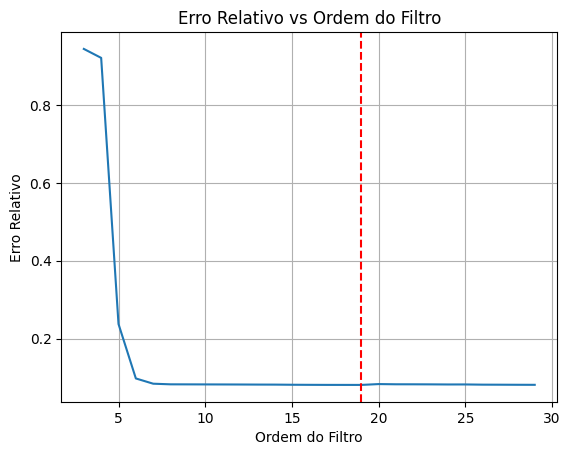

In [87]:
plt.plot(ordens, erros)
plt.axvline(19, linestyle="--", color="red")
# plt.xlim(6,23)
# plt.ylim(0,0.20)
plt.xlabel("Ordem do Filtro")
plt.ylabel("Erro Relativo")
plt.title("Erro Relativo vs Ordem do Filtro")
plt.grid(True)
plt.show()

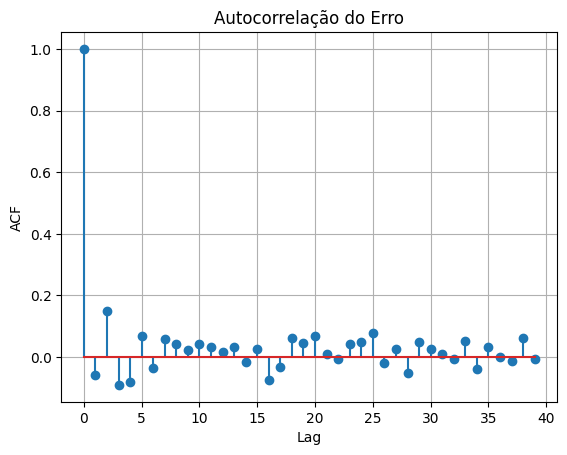

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def autocorrelacao(x):
    result = np.correlate(x, x, mode="full")
    return result[result.size // 2 :]


erro = erro - np.mean(erro)

acf = autocorrelacao(erro)
acf = acf / acf[0]  # normalizar

plt.stem(acf[:40])
plt.title("Autocorrelação do Erro")
plt.xlabel("Lag")
plt.ylabel("ACF")
plt.grid()
plt.show()

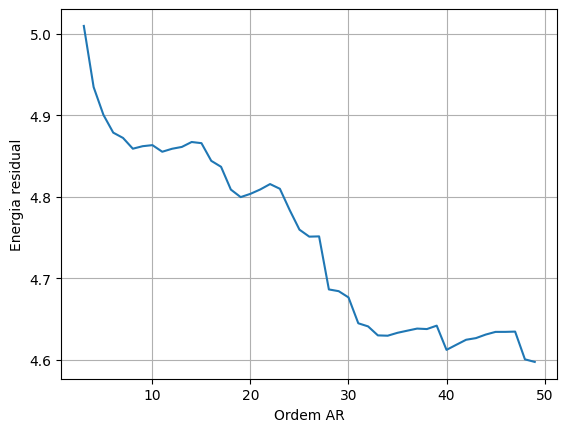

In [ ]:
def ajustar_AR(erro, ordem):
    erro = erro - np.mean(erro)

    N = len(erro)

    Y = erro[ordem:]

    X = np.column_stack([erro[ordem - i - 1 : N - i - 1] for i in range(ordem)])

    coef = np.linalg.pinv(X) @ Y

    return coef


ordens_ar = range(3, 50)
energia_residual = []

for p in ordens_ar:
    coef = ajustar_AR(erro, p)

    N = len(erro)
    Y = erro[p:]
    X = np.column_stack([erro[p - i - 1 : N - i - 1] for i in range(p)])

    erro_residual = Y - X @ coef

    energia = np.mean(erro_residual**2)
    energia_residual.append(energia)

plt.plot(ordens_ar, energia_residual)
plt.xlabel("Ordem AR")
plt.ylabel("Energia residual")
plt.grid()
plt.show()

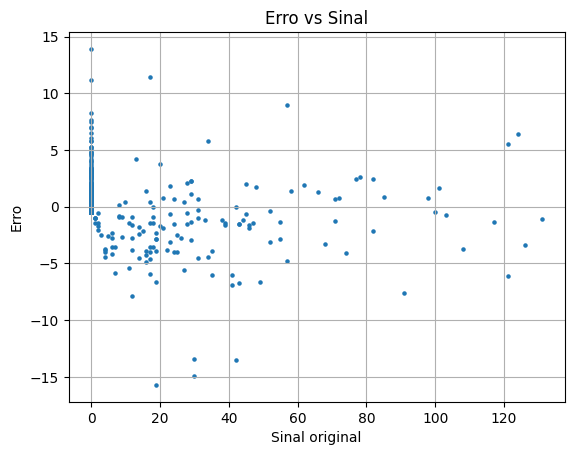

In [ ]:
plt.scatter(sinal_original[: len(erro)], erro, s=5)
plt.xlabel("Sinal original")
plt.ylabel("Erro")
plt.title("Erro vs Sinal")
plt.grid()
plt.show()

In [ ]:
X_nl = np.column_stack(
    [sinal_original[: len(erro)], sinal_original[: len(erro)] ** 2, np.ones(len(erro))]
)

coef_nl = np.linalg.pinv(X_nl) @ erro

erro_novo = erro - X_nl @ coef_nl

print("Energia antes:", np.mean(erro**2))
print("Energia depois:", np.mean(erro_novo**2))

Energia antes: 5.148922810205965
Energia depois: 4.550928016765013
